# Adiantando a saida

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../Data.csv")
data = data.drop(columns=["VD", "VE", "tempo"])
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

data["theta"] = data["theta(Wd,We)"]
data["theta(Wd,We)"] = data["theta(Wd,We)"].shift(1)
data["Wd-We"] = data["Wd"] - data["We"]


data = data.iloc[1:]

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

PREDICTORS = ["Wd-We"]
TARGET = ["theta(Wd,We)", "theta"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    for preds in PREDICTORS:
        sns.lineplot(x=df.index, y=df[preds], ax=ax1, marker="o", label=preds,  linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        for target in TARGET:
            sns.lineplot(x=df.index, y=df[target], ax=ax2, marker="o", label=target, linestyle="dashed", linewidth=2)
            ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Salvando o gráfico
    plt.savefig(f"content/figs/{img_name}", format="svg", dpi=600)

    # Exibindo o gráfico
    plt.show()


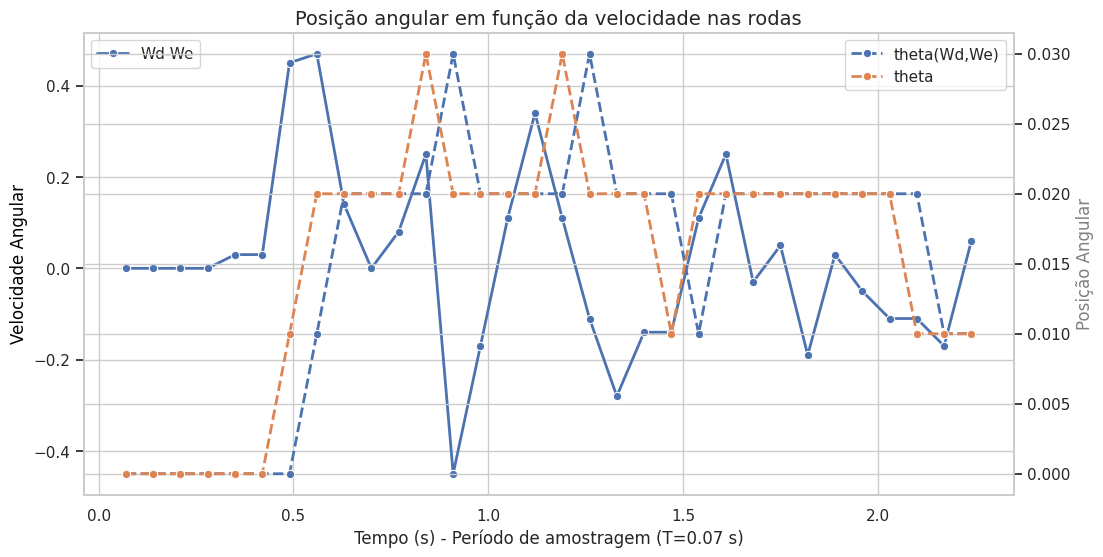

In [8]:
PlotTimeSeries(data.head(32))

In [25]:
from pykrige.ok import OrdinaryKriging
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error

PREDICTORS = ["Wd-We", "theta"]
TARGET = "theta(Wd,We)"

VARIOGRAMS = ["gaussian", 'exponential', "spherical", "hole-effect", "power", "linear"]

class Kriging2D:

    def __init__(self, Dataset):
        train_data, test_data = train_test_split(Dataset, test_size=0.25, shuffle=False)

        self.train_samples_x = np.array(train_data[PREDICTORS])
        self.train_samples_y = np.array(train_data[TARGET])

        self.test_samples_x = np.array(test_data[PREDICTORS])
        self.test_samples_y = np.array(test_data[TARGET])

        self.train_time = Dataset.head(len(self.train_samples_y)).index
        self.test_time = Dataset.tail(len(self.test_samples_y)).index

        self.kriging_model = None

    def BuildModel(self, VariogramType):
        self.kriging_model = OrdinaryKriging(
            self.train_samples_x[:, 0],  # Wd-We
            self.train_samples_x[:, 1],  # theta
            self.train_samples_y,
            variogram_model=VariogramType
        )

    def ComputeMetrics(self):
        self.train_pred, _ = self.kriging_model.execute(
            'points',
            self.train_samples_x[:, 0],
            self.train_samples_x[:, 1]
        )

        self.test_pred, _ = self.kriging_model.execute(
            'points',
            self.test_samples_x[:, 0],
            self.test_samples_x[:, 1]
        )

        return {
            'r2_training': r2_score(self.train_samples_y, self.train_pred),
            'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
            'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
            'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

            'r2_test': r2_score(self.test_samples_y, self.test_pred),
            'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
            'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
            'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
        }

    def PlotOut(self, variogram):
        sns.set_theme(style="whitegrid")

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

        sns.lineplot(x=self.train_time, y=self.train_pred, ax=ax1, marker="o", label="train_pred", linewidth=2)
        sns.lineplot(x=self.train_time, y=self.train_samples_y, ax=ax1, marker="o", label="train_orig", linewidth=2)
        ax1.set_title("Dados de Treinamento", fontsize=13)
        ax1.set_xlabel("Tempo (s)", fontsize=12)
        ax1.set_ylabel("Velocidade Angular", fontsize=12)
        ax1.legend()

        sns.lineplot(x=self.test_time, y=self.test_pred, ax=ax2, marker="o", label="test_pred", linewidth=2)
        sns.lineplot(x=self.test_time, y=self.test_samples_y, ax=ax2, marker="o", label="test_orig", linewidth=2)
        ax2.set_title("Dados de Teste", fontsize=13)
        ax2.set_xlabel("Tempo (s)", fontsize=12)
        ax2.legend()

        fig.suptitle(f"Resultados do modelo Kriging 2D: {variogram}", fontsize=15)

        plt.savefig(f"content/figs/{variogram}.svg", format="svg", dpi=600)

        plt.show()

    def EvalModel(self, excel_path):
        self.models = {}
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            for variogram in VARIOGRAMS:
                self.BuildModel(VariogramType=variogram)
                metrics = self.ComputeMetrics()
                self.models[variogram] = self.kriging_model

                display(metrics)
                df = pd.DataFrame([metrics])
                df.to_excel(writer, sheet_name=variogram, index=False)
                self.PlotOut(variogram)


{'r2_training': 0.9998414312776928,
 'mse_training': 2.1881656750955512e-05,
 'mape_training': 3281528819755.1313,
 'rmse_training': 0.004677783315947363,
 'r2_test': -6326.814498533091,
 'mse_test': 143.04975604877396,
 'mape_test': 11.017364165671106,
 'rmse_test': 11.960340967078404}

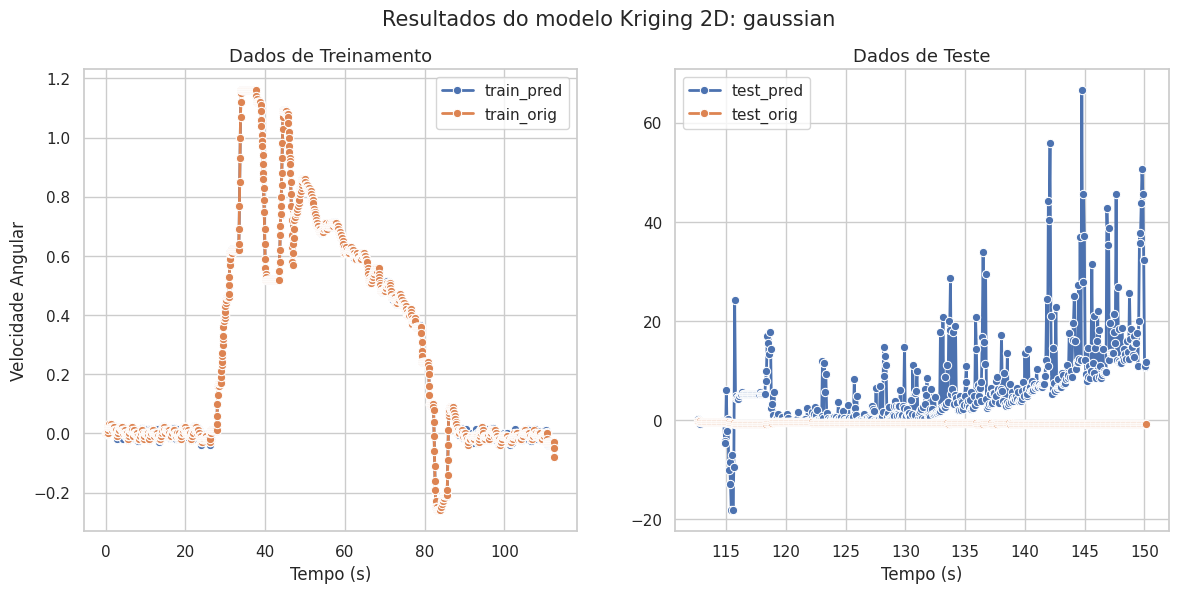

{'r2_training': 0.9999629644950072,
 'mse_training': 5.1107065508193065e-06,
 'mape_training': 1241392799124.8032,
 'rmse_training': 0.0022606871855299455,
 'r2_test': -17.569296968227732,
 'mse_test': 0.4197868635242079,
 'mape_test': 0.9418852730605731,
 'rmse_test': 0.6479096106126285}

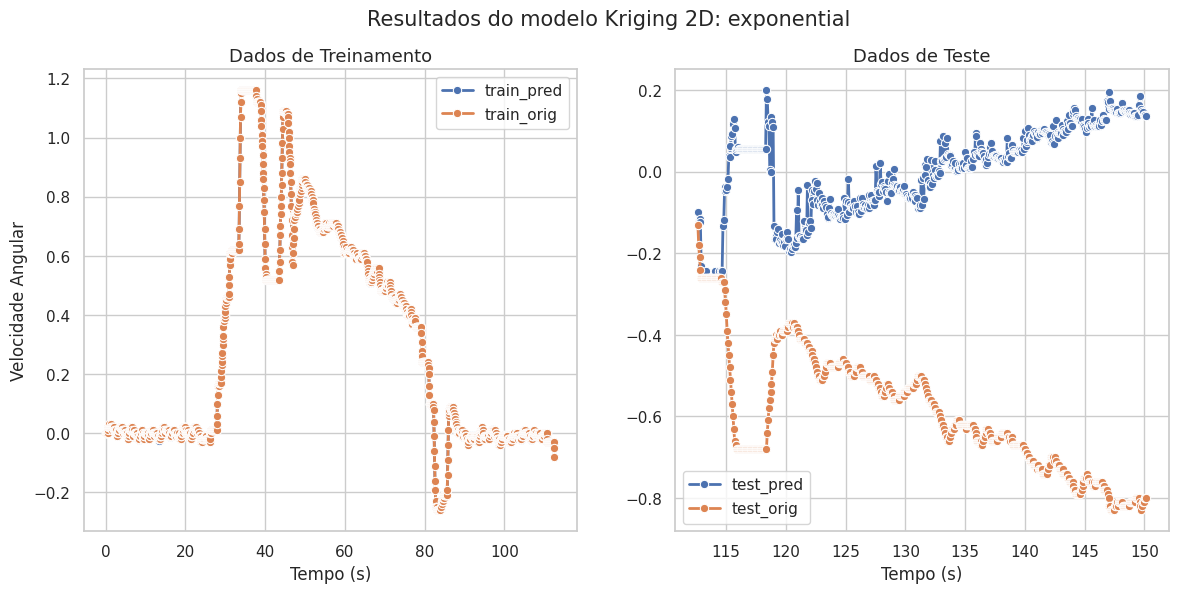

{'r2_training': 0.9997059837441632,
 'mse_training': 4.057271002636347e-05,
 'mape_training': 2165088545528.7283,
 'rmse_training': 0.006369671108178465,
 'r2_test': -12.367625582178796,
 'mse_test': 0.3021952648778373,
 'mape_test': 0.7915559566214717,
 'rmse_test': 0.5497228982658784}

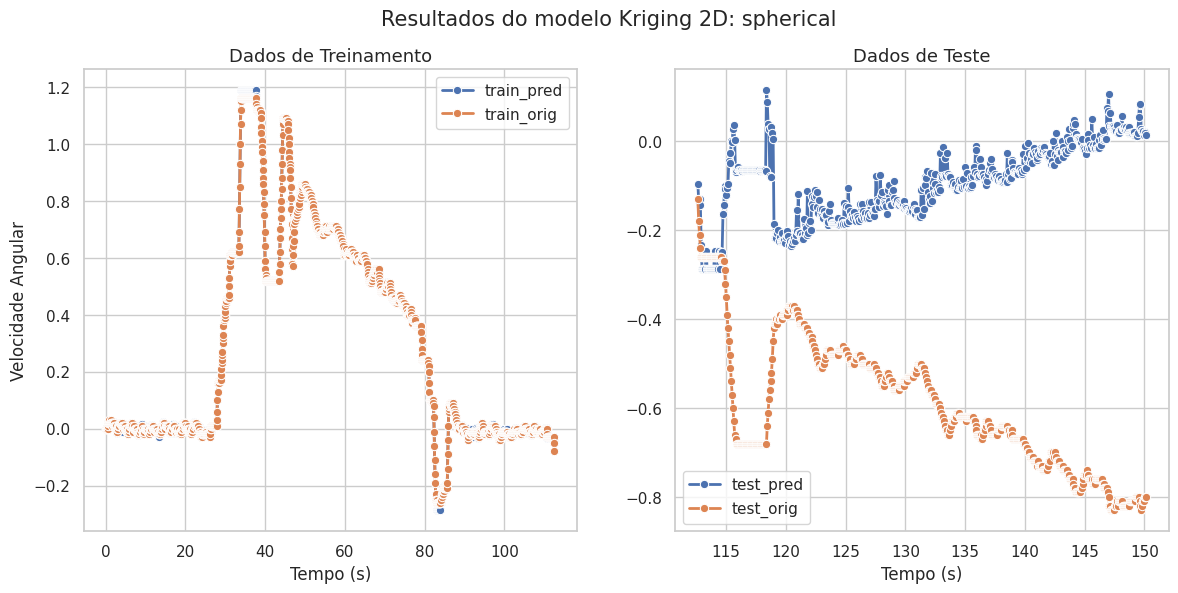

{'r2_training': 0.9792418915606318,
 'mse_training': 0.0028645107122032515,
 'mape_training': 26013999101092.344,
 'rmse_training': 0.05352112398112778,
 'r2_test': -21.678013037047958,
 'mse_test': 0.5126705647538604,
 'mape_test': 1.024169636718061,
 'rmse_test': 0.7160101708452614}

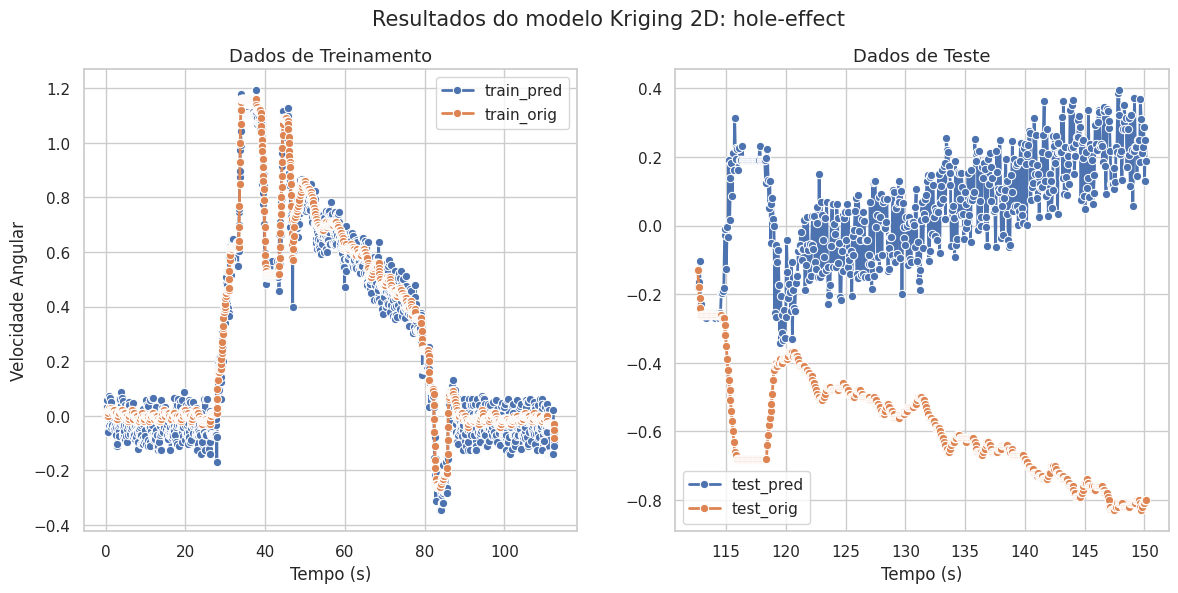

{'r2_training': 0.999959933251436,
 'mse_training': 5.529002355879883e-06,
 'mape_training': 1401327022146.3306,
 'rmse_training': 0.0023513830729763882,
 'r2_test': -18.697624215083533,
 'mse_test': 0.44529439656635456,
 'mape_test': 1.0480751089824965,
 'rmse_test': 0.6673038262788207}

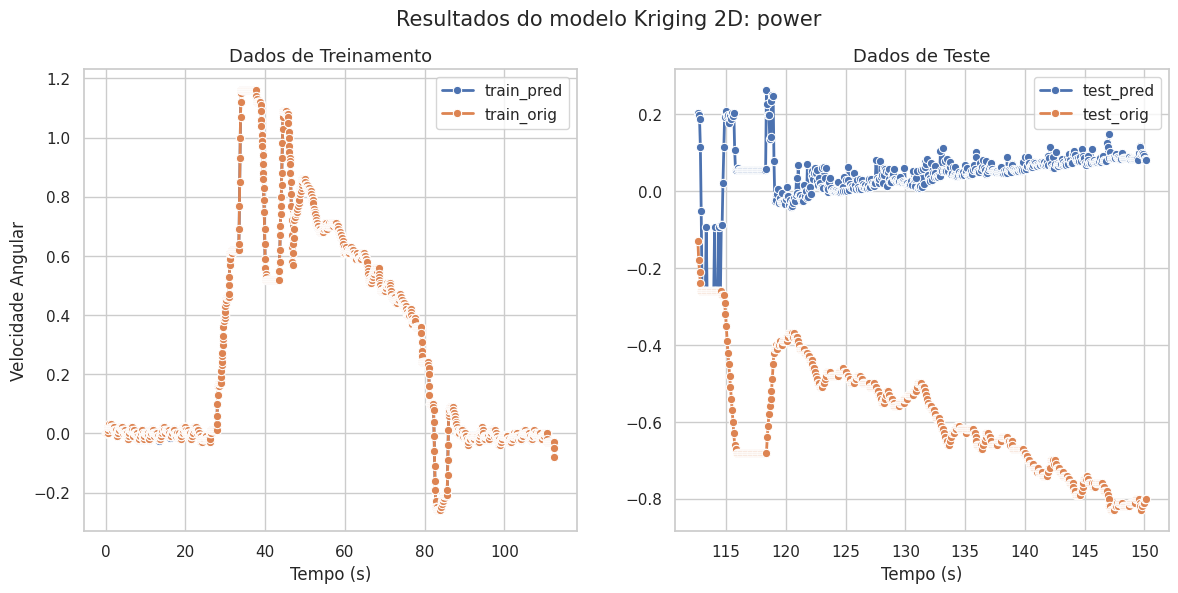

{'r2_training': -418.8484256247547,
 'mse_training': 57.93689324904536,
 'mape_training': 881856854259673.0,
 'rmse_training': 7.611628817082804,
 'r2_test': -96.69280730331381,
 'mse_test': 2.2084927198321918,
 'mape_test': 2.350140734043305,
 'rmse_test': 1.4860998350824859}

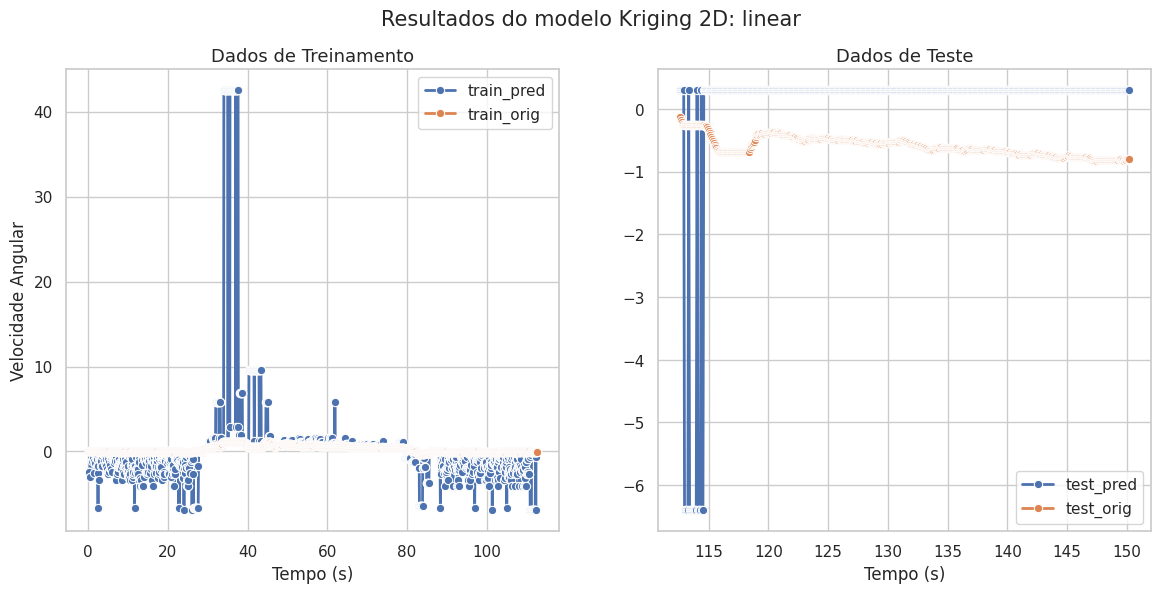

In [26]:
Vsg = Kriging2D(Dataset=data)        
Vsg.EvalModel("./content/KrigingMetrics.xlsx")

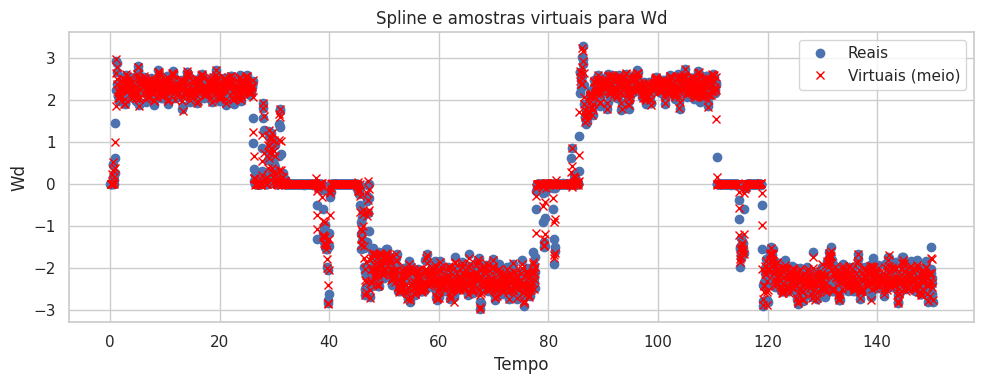

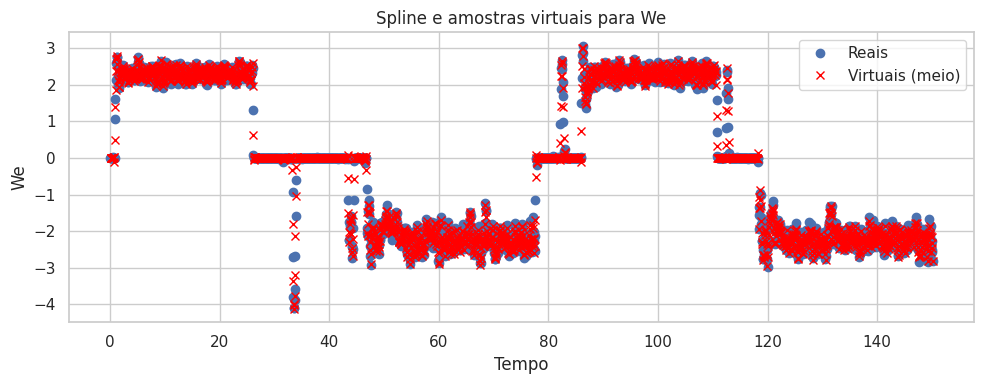

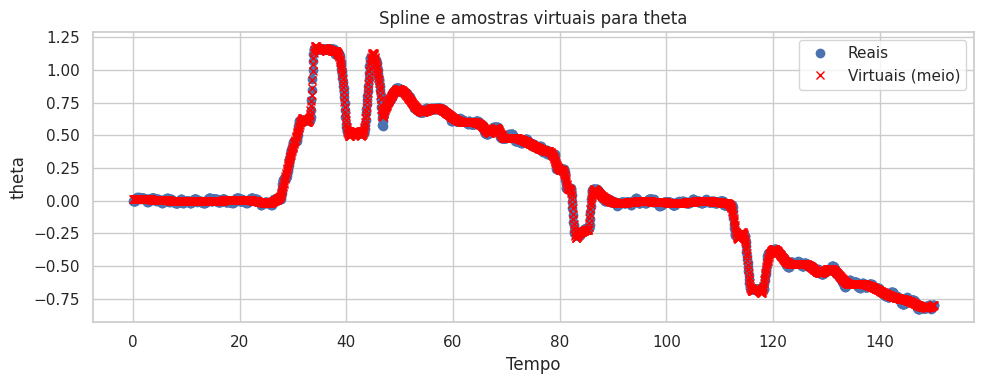

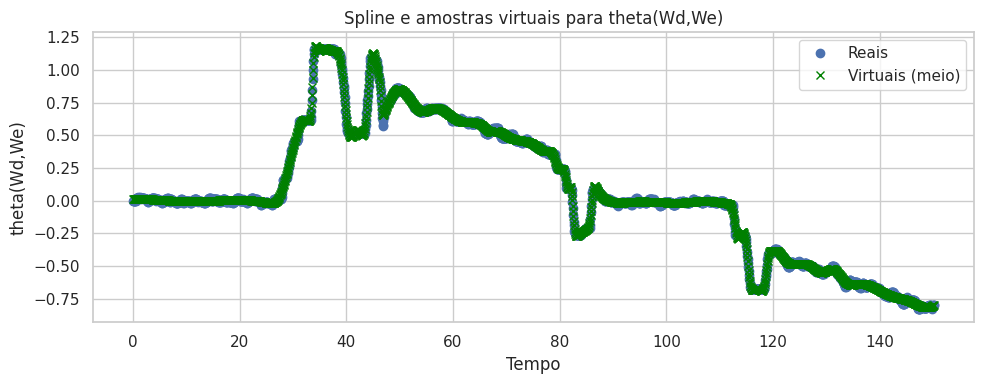

In [16]:
from scipy.interpolate import UnivariateSpline
import pandas as pd
import matplotlib.pyplot as plt
PREDICTORS = ["Wd", "We", "theta"]
TARGET = "theta(Wd,We)"

def ComputeVirtualDim(Dataset):
    tempo = Dataset.index.to_numpy()

    # Tempo virtual: entre pares consecutivos
    tempo_virtual = ((tempo[:-1] + tempo[1:]) / 2).round(5)

    virtual_data = {
        "tempo_virtual": tempo_virtual
    }

    for pred in PREDICTORS:
        y = Dataset[pred].to_numpy()
        spline = UnivariateSpline(tempo, y, s=0.5)

        y_virtual = spline(tempo_virtual)
        virtual_data[pred] = y_virtual

        plt.figure(figsize=(10, 4))
        plt.plot(tempo, y, 'o', label='Reais')
        plt.plot(tempo_virtual, y_virtual, 'x', color='red', label='Virtuais (meio)')
        plt.xlabel("Tempo")
        plt.ylabel(pred)
        plt.title(f"Spline e amostras virtuais para {pred}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    y_target = Dataset[TARGET].to_numpy()
    spline_target = UnivariateSpline(tempo, y_target, s=0.5)
    target_virtual = spline_target(tempo_virtual)
    virtual_data[f'{TARGET}_spline'] = target_virtual

    plt.figure(figsize=(10, 4))
    plt.plot(tempo, y_target, 'o', label='Reais')
    plt.plot(tempo_virtual, target_virtual, 'x', color='green', label='Virtuais (meio)')
    plt.xlabel("Tempo")
    plt.ylabel(TARGET)
    plt.title(f"Spline e amostras virtuais para {TARGET}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(virtual_data)

VirtualDataset = ComputeVirtualDim(Dataset=data)


In [17]:
VirtualDataset

,tempo_virtual,Wd,We,theta,"theta(Wd,We)_spline"
0,0.105,-0.001309,0.000267,0.015522,0.013392
1,0.175,0.001421,0.001046,0.015410,0.013410
2,0.245,-0.005407,0.000521,0.015297,0.013424
3,0.315,0.025778,-0.000455,0.015182,0.013432
4,0.385,-0.009302,-0.001025,0.015064,0.013435
...,...,...,...,...,...
2139,149.835,-1.762927,-2.126779,-0.805389,-0.806898
2140,149.905,-1.797347,-2.153000,-0.803555,-0.805252
2141,149.975,-2.367411,-2.455179,-0.801583,-0.803476
2142,150.045,-2.464167,-2.331821,-0.799469,-0.801568


In [21]:
VirtualDataset["Wd"] - VirtualDataset["We"]

0      -0.001576
1       0.000375
2      -0.005928
3       0.026232
4      -0.008276
          ...   
2139    0.363852
2140    0.355653
2141    0.087769
2142   -0.132346
2143    0.057259
Length: 2144, dtype: float64

In [22]:
for variogram in VARIOGRAMS:
    model = Vsg.models[variogram]
    
    VirtualDataset[f'{TARGET}_{variogram}'] = model.execute(
                                            'points',
                                            VirtualDataset["Wd"] - VirtualDataset["We"],
                                            VirtualDataset["theta"])[0]
        
    
VirtualDataset.to_excel("./content/VirtualData.xlsx")

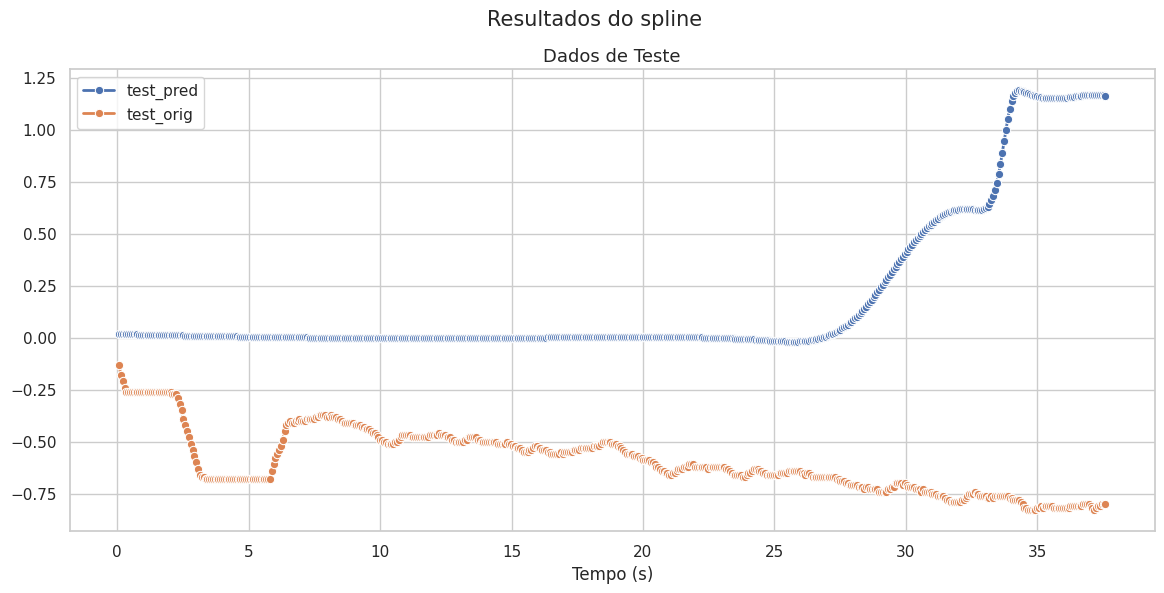

In [23]:
train_time = data.head(np.size(Vsg.train_samples_y)).index
test_time = data.head(np.size(Vsg.test_samples_y)).index

spline = UnivariateSpline(train_time, Vsg.train_samples_y, s=0.5)
test_spline = spline(test_time)

spline_metrics = {
'r2_test': r2_score(Vsg.test_samples_y, test_spline),
'mse_test': mean_squared_error(Vsg.test_samples_y, test_spline),
'mape_test': mean_absolute_percentage_error(Vsg.test_samples_y, test_spline),
'rmse_test': root_mean_squared_error(Vsg.test_samples_y, test_spline),
}

spline_metrics_df = pd.DataFrame([spline_metrics])

# Salva em nova aba no arquivo Excel
with pd.ExcelWriter("./content/KrigingMetrics.xlsx", mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
    spline_metrics_df.to_excel(writer, sheet_name="SplineMetrics", index=False)

sns.set_theme(style="whitegrid")

fig, ax2 = plt.subplots(1, 1, figsize=(14, 6), sharey=False)

sns.lineplot(x=test_time, y=test_spline, ax=ax2, marker="o", label="test_pred", linewidth=2)
sns.lineplot(x=test_time, y=Vsg.test_samples_y, ax=ax2, marker="o", label="test_orig", linewidth=2)
ax2.set_title("Dados de Teste", fontsize=13)
ax2.set_xlabel("Tempo (s)", fontsize=12)
ax2.legend()

fig.suptitle(f"Resultados do spline", fontsize=15)


plt.savefig(f"content/spline.svg", format="svg", dpi=600)

plt.show()

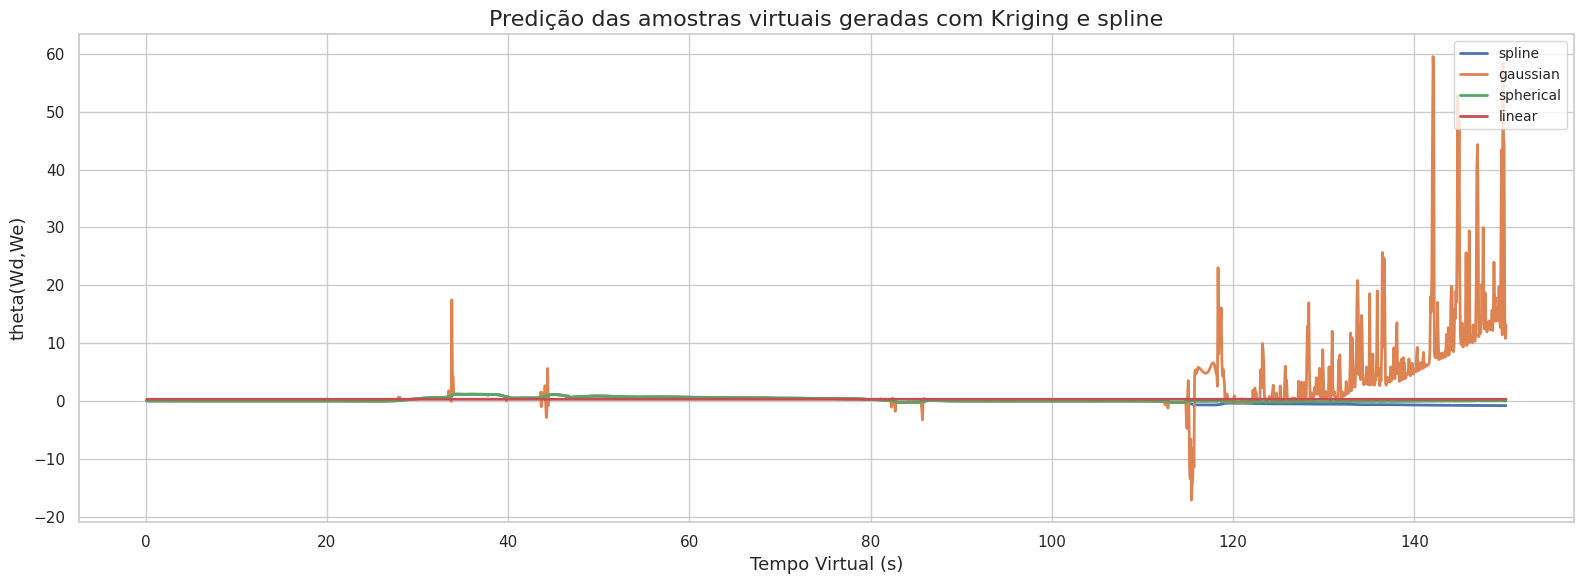

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o arquivo com as amostras virtuais
virtual_df = pd.read_excel("./content/VirtualData.xlsx")

# Define o tempo
tempo_virtual = virtual_df["tempo_virtual"]

# Define as colunas de predição
model_cols = [
    "theta(Wd,We)_spline",
    "theta(Wd,We)_gaussian",
    "theta(Wd,We)_spherical",
    # "theta(Wd,We)_hole-effect",
    # "theta(Wd,We)_power",
    "theta(Wd,We)_linear"
]

# Configura o estilo
sns.set_theme(style="whitegrid")

# Cria figura e eixos
fig, ax1 = plt.subplots(figsize=(16, 6))

# Plot das predições (eixo esquerdo)
for col in model_cols:
    ax1.plot(tempo_virtual, virtual_df[col], label=col.split("_")[-1], linewidth=2)

ax1.set_xlabel("Tempo Virtual (s)", fontsize=13)
ax1.set_ylabel("theta(Wd,We)", fontsize=13)
ax1.legend(title="Modelo", loc="upper left")
ax1.grid(True)

# # Segundo eixo y (eixo direito) para Wd e We
# ax2 = ax1.twinx()
# ax2.plot(tempo_virtual, virtual_df["Wd"], color="black", linestyle="--", label="Wd", alpha=0.6)
# ax2.plot(tempo_virtual, virtual_df["We"], color="gray", linestyle="-.", label="We", alpha=0.6)
# ax2.set_ylabel("Wd / We", fontsize=13)

# Combina as legendas
lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc="upper right", fontsize=10)

# Título e layout
plt.title("Predição das amostras virtuais geradas com Kriging e spline", fontsize=16)
plt.tight_layout()
plt.savefig("content/figs/virtualPredictions.svg", format="svg", dpi=600)
plt.show()
